# **FM3054– Portfolio Optimization**
# **Mid-Term Take-Home Assignment**

## **Retreive Stock Prices**

In [24]:
import yfinance as yf

# 1. Define the Tickers and Date Range
tickers = ['AAPL', 'JNJ', 'JPM', 'NEE', 'PG','COST','^GSPC']
start_date = '2023-01-10'
end_date = '2026-01-10'

print("Downloading data...")

# 2. Download Data
# auto_adjust=True makes 'Close' the adjusted price, avoiding 'Adj Close' issues
data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True)

# 3. Extract the 'Close' price safely
# If auto_adjust=True, we use 'Close'. If False, we might look for 'Adj Close'
if 'Close' in data.columns:
    prices = data['Close']
elif 'Adj Close' in data.columns:
    prices = data['Adj Close']
else:
    # Fallback: Just take the whole dataframe if it's already single-level
    prices = data

# 4. Data Cleaning (Crucial for your Assignment)
# Check if any stock is missing significant data (like NNE)
print("\n--- Missing Data Check (Count of NaNs) ---")
print(prices.isna().sum())

# Optional: Drop columns that have too much missing data (e.g., NNE)
# if you want to strictly follow the "3 years data" rule:
# prices = prices.dropna(axis=1, how='any')

# 5. Display and Save
print("\n--- Final Data Preview ---")
print(prices.head())
print(f"\nDate Range: {prices.index.min().date()} to {prices.index.max().date()}")





[********************* 43%                       ]  3 of 7 completed

[*********************100%***********************]  7 of 7 completed


--- Missing Data Check (Count of NaNs) ---
Ticker
AAPL     0
COST     0
JNJ      0
JPM      0
NEE      0
PG       0
^GSPC    0
dtype: int64

--- Final Data Preview ---
Ticker            AAPL        COST         JNJ         JPM        NEE  \
Date                                                                    
2023-01-10  128.787109  462.035156  159.890030  129.092789  77.475365   
2023-01-11  131.506073  464.828125  159.634430  130.052139  77.896912   
2023-01-12  131.427277  463.023712  158.831177  129.921753  77.961067   
2023-01-13  132.757172  465.730286  158.310852  133.200272  77.603653   
2023-01-17  133.919647  467.189148  157.334122  131.141861  78.575073   

Ticker              PG        ^GSPC  
Date                                 
2023-01-10  140.811127  3919.250000  
2023-01-11  139.670853  3969.610107  
2023-01-12  138.882858  3983.169922  
2023-01-13  139.874771  3999.090088  
2023-01-17  139.466873  3990.969971  

Date Range: 2023-01-10 to 2026-01-09


## **Part A: Data Preparation and Exploratory Analysis**

### **a)**

In [25]:
import numpy as np
import pandas as pd

# This assumes 'prices' dataframe exists from your previous code block

# 1. Calculate Daily Returns
# We drop the first row because it becomes NaN (no previous day to compare)
daily_returns = np.log(prices / prices.shift(1)).dropna()

# 2. Calculate Annualized Metrics
# Financial convention assumes 252 trading days in a year
annual_returns = daily_returns.mean() * 252
annual_std = daily_returns.std() * np.sqrt(252)

# 3. Combine into a clear Summary Table
summary_df = pd.DataFrame({
    'Annualized Return': annual_returns,
    'Annualized Std Dev (Volatility)': annual_std
})

# 4. Display the results nicely
print("\n--- Annualized Performance Metrics ---")
# format="{:.2%}" makes it look like 12.50% instead of 0.125
print(summary_df.style.format("{:.2%}").to_string())


--- Annualized Performance Metrics ---
 Annualized Return Annualized Std Dev (Volatility)
Ticker  
AAPL 23.46% 25.38%
COST 23.26% 19.67%
JNJ 8.23% 17.15%
JPM 31.37% 23.10%
NEE 1.03% 27.42%
PG 0.25% 16.42%
^GSPC 19.27% 14.95%



In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Separate Stocks from Benchmark
# We remove '^GSPC' (S&P 500) because we don't "hold" the index in the portfolio optimization
# We only use it later for CAPM Beta calculations.
stock_list = [t for t in tickers if t != '^GSPC']
stock_returns = daily_returns[stock_list]

# 2. Calculate Annualized Covariance Matrix
# Formula: Daily Covariance * 252
annual_cov_matrix = stock_returns.cov() * 252

# 3. Calculate Correlation Matrix
# Correlation is dimensionless (between -1 and 1), so we don't multiply by 252.
corr_matrix = stock_returns.corr()

# 4. Display Matrices
print("\n--- Annualized Covariance Matrix (Stocks Only) ---")
print(annual_cov_matrix)

print("\n--- Correlation Matrix ---")
print(corr_matrix)




--- Annualized Covariance Matrix (Stocks Only) ---
Ticker      AAPL       JNJ       JPM       NEE        PG      COST
Ticker                                                            
AAPL    0.064408  0.002588  0.017542  0.009409  0.005972  0.016784
JNJ     0.002588  0.029427  0.006003  0.012638  0.010167  0.002932
JPM     0.017542  0.006003  0.053372  0.007184  0.002938  0.010973
NEE     0.009409  0.012638  0.007184  0.075166  0.015065  0.005202
PG      0.005972  0.010167  0.002938  0.015065  0.026974  0.008920
COST    0.016784  0.002932  0.010973  0.005202  0.008920  0.038700

--- Correlation Matrix ---
Ticker      AAPL       JNJ       JPM       NEE        PG      COST
Ticker                                                            
AAPL    1.000000  0.059452  0.299190  0.135224  0.143287  0.336177
JNJ     0.059452  1.000000  0.151476  0.268708  0.360852  0.086887
JPM     0.299190  0.151476  1.000000  0.113419  0.077426  0.241444
NEE     0.135224  0.268708  0.113419  1.000000  0

### **b)**

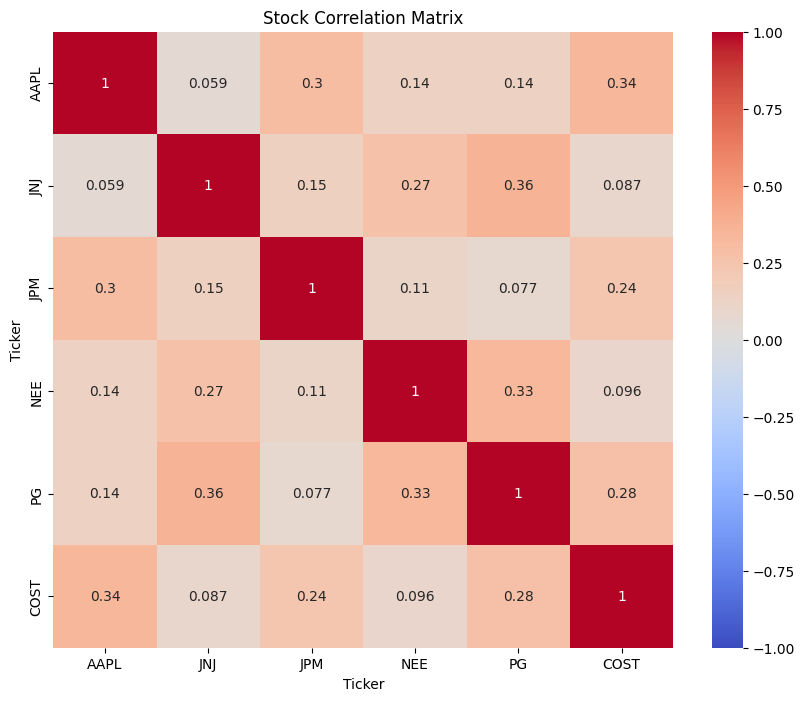

In [27]:
#  Visualize Correlation Matrix (Heatmap)
# This satisfies "Part A: Visualize Correlation structure" from your assignment
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Stock Correlation Matrix')
plt.show()

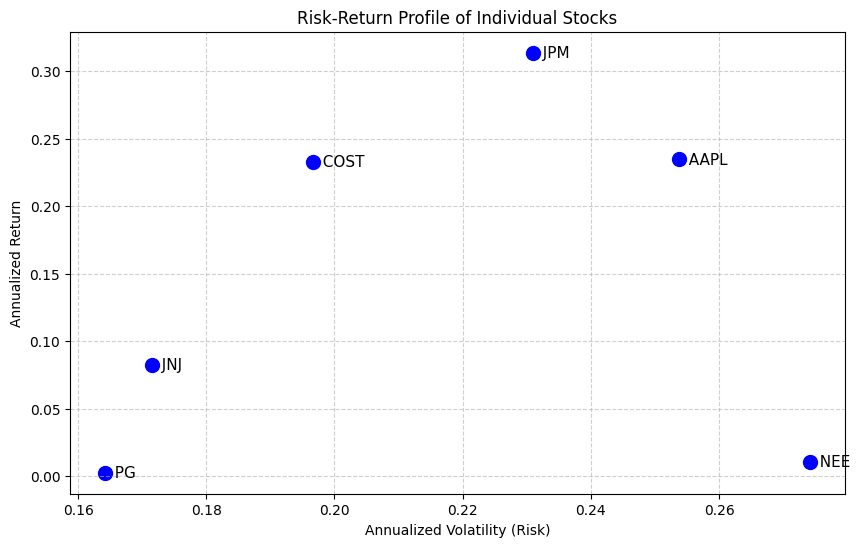

In [28]:
# 6. Visualize Risk-Return Profile (Individual Stocks)
# This satisfies "Part A: Visualize Risk-return profiles of individual assets"
stock_annual_return = stock_returns.mean() * 252
stock_annual_volatility = stock_returns.std() * np.sqrt(252)

plt.figure(figsize=(10, 6))
plt.scatter(stock_annual_volatility, stock_annual_return, marker='o', s=100, color='blue')

# Annotate each point with the ticker name
for ticker in stock_list:
    plt.text(stock_annual_volatility[ticker], stock_annual_return[ticker],
             f"  {ticker}", fontsize=11, verticalalignment='center')

plt.title('Risk-Return Profile of Individual Stocks')
plt.xlabel('Annualized Volatility (Risk)')
plt.ylabel('Annualized Return')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## **Part B**

In [29]:
# ========================================================
# PART B: PORTFOLIO CONSTRUCTION (REFACTORED & CLEANED)
# ========================================================
# This script performs Mean-Variance Optimization to construct:
# 1. Minimum Volatility Portfolios
# 2. Maximum Sharpe Ratio Portfolios
# 3. Equal-Weighted Benchmark
# *Includes both Long-Only and Short-Selling scenarios*

import numpy as np
import pandas as pd
from scipy.optimize import minimize
from IPython.display import display

# -------------------------------
# 1. SETUP & INPUTS
# -------------------------------
# Ensure 'stock_returns' is defined from Part A
# If running standalone, uncomment the line below with your data
# stock_returns = daily_returns[stock_list]

risk_free_rate = 0.0417        # 4.17% Annual Risk-Free Rate
mu = stock_returns.mean() * 252  # Annualized Expected Returns
Sigma = stock_returns.cov() * 252 # Annualized Covariance Matrix
n_assets = len(mu)

# -------------------------------
# 2. CORE FUNCTIONS
# -------------------------------
def get_metrics(weights, mu, Sigma, rf):
    """Returns (Expected Return, Volatility, Sharpe Ratio) for given weights."""
    ret = np.dot(weights, mu)
    vol = np.sqrt(weights.T @ Sigma @ weights)
    sharpe = (ret - rf) / vol
    return ret, vol, sharpe

# Objective Functions for Optimization
def min_vol_func(w, Sigma):
    return np.sqrt(w.T @ Sigma @ w)

def max_sharpe_func(w, mu, Sigma, rf):
    # We minimize negative Sharpe to maximize positive Sharpe
    return -get_metrics(w, mu, Sigma, rf)[2]

# -------------------------------
# 3. OPTIMIZATION LOOP
# -------------------------------
# Initial Guess (Equal weights)
w0 = np.full(n_assets, 1/n_assets)

# Constraint: Weights must sum to 1
constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})

# Define the scenarios to run
strategies = [
    ("Min Volatility", min_vol_func, (Sigma,)),
    ("Max Sharpe Ratio", max_sharpe_func, (mu, Sigma, risk_free_rate))
]

# Define bounds settings
bounds_configs = [
    ("No Short", tuple((0, 1) for _ in range(n_assets))),      # Long Only
    ("Short Allowed", tuple((-1, 1) for _ in range(n_assets))) # Short Selling (-100% to 100%)
]

# Storage for results
results_weights = {}
results_metrics = []

print("Running Optimizations...")

# Loop through every combination of Strategy + Constraint
for strategy_name, objective_func, args in strategies:
    for bounds_name, bounds in bounds_configs:
        full_name = f"{strategy_name} ({bounds_name})"

        # Run Optimization
        opt = minimize(objective_func, w0, args=args, method='SLSQP',
                       bounds=bounds, constraints=constraints)

        # Store Results
        results_weights[full_name] = opt.x
        ret, vol, sharpe = get_metrics(opt.x, mu, Sigma, risk_free_rate)
        results_metrics.append([full_name, ret, vol, sharpe])

# Add Equal-Weighted Benchmark Manually
ew_name = "Equal-Weighted Portfolio"
results_weights[ew_name] = w0
ret, vol, sharpe = get_metrics(w0, mu, Sigma, risk_free_rate)
results_metrics.append([ew_name, ret, vol, sharpe])

# -------------------------------
# 4. OUTPUT & FORMATTING
# -------------------------------
# Create DataFrames
df_weights = pd.DataFrame(results_weights, index=mu.index).T
df_weights.index.name = 'Portfolio'

df_metrics = pd.DataFrame(results_metrics,
                          columns=['Portfolio', 'Expected Return', 'Volatility', 'Sharpe Ratio'])
df_metrics.set_index('Portfolio', inplace=True)

# Apply Styling (Publication Ready)
styled_weights = df_weights.style.format("{:.2%}") \
    .background_gradient(cmap='Blues', axis=1) \
    .set_caption("Table 1: Optimized Portfolio Weights")

styled_metrics = df_metrics.style.format({
    'Expected Return': '{:.2%}',
    'Volatility': '{:.2%}',
    'Sharpe Ratio': '{:.2f}'
}).background_gradient(cmap='Greens', axis=0) \
  .set_caption("Table 2: Performance Metrics")

# Display Results
print("\n--- OPTIMIZATION COMPLETE ---")
display(styled_weights)
display(styled_metrics)



Running Optimizations...

--- OPTIMIZATION COMPLETE ---


Ticker,AAPL,JNJ,JPM,NEE,PG,COST
Portfolio,,,,,,
Min Volatility (No Short),8.14%,29.31%,13.22%,3.97%,26.96%,18.40%
Min Volatility (Short Allowed),8.14%,29.31%,13.22%,3.97%,26.96%,18.40%
Max Sharpe Ratio (No Short),11.89%,1.49%,47.60%,0.00%,0.00%,39.02%
Max Sharpe Ratio (Short Allowed),19.03%,25.73%,61.05%,-11.89%,-57.13%,63.20%
Equal-Weighted Portfolio,16.67%,16.67%,16.67%,16.67%,16.67%,16.67%


,Expected Return,Volatility,Sharpe Ratio
Portfolio,,,
Min Volatility (No Short),12.86%,11.57%,0.75
Min Volatility (Short Allowed),12.86%,11.57%,0.75
Max Sharpe Ratio (No Short),26.92%,16.32%,1.39
Max Sharpe Ratio (Short Allowed),40.17%,23.54%,1.53
Equal-Weighted Portfolio,14.60%,12.44%,0.84


## **Part C: Efficient Frontier Analysis**

Calculating Efficient Frontier and Random Portfolios...


/tmp/ipython-input-2111484787.py:99: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.annotate(txt, (stock_vols[i], mu[i]), xytext=(6,0), textcoords='offset points', fontsize=10, weight='bold')


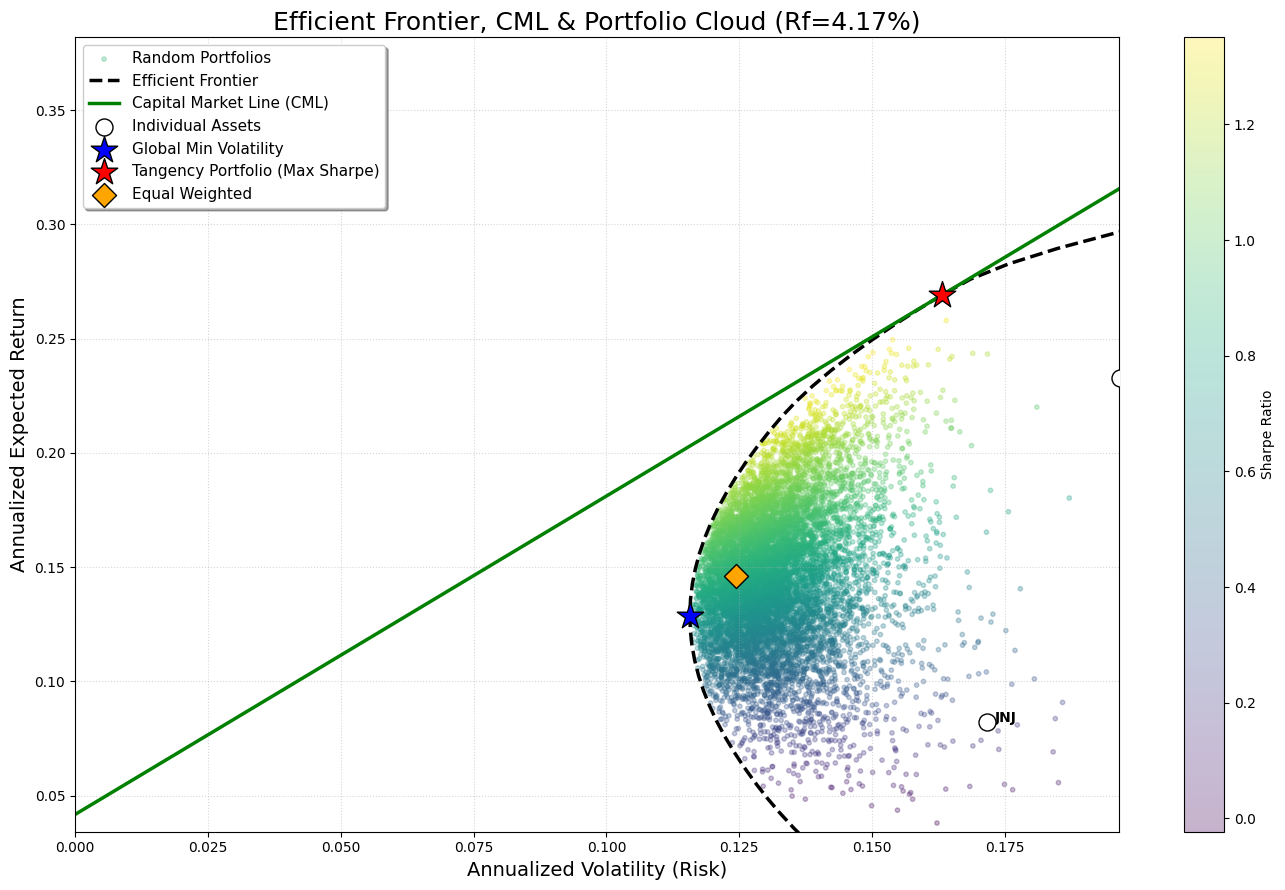

Efficient Frontier with Portfolio Cloud plotted.


In [30]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as sco
import pandas as pd

# ========================================================
# PART C: EFFICIENT FRONTIER & CML (Enhanced Visualization)
# ========================================================

# Ensure these variables exist from previous steps:
# mu, Sigma, risk_free_rate, results_metrics (list from Part B)

print("Calculating Efficient Frontier and Random Portfolios...")

# --- 1. Monte Carlo Simulation for Feasible Set ---
# This generates thousands of random portfolios to visualize the "cloud"
num_portfolios = 10000
all_weights = np.zeros((num_portfolios, len(mu)))
ret_arr = np.zeros(num_portfolios)
vol_arr = np.zeros(num_portfolios)
sharpe_arr = np.zeros(num_portfolios)

for i in range(num_portfolios):
    # Generate random weights
    weights = np.random.random(len(mu))
    weights /= np.sum(weights)  # Normalize to sum to 1

    # Save weights
    all_weights[i, :] = weights

    # Expected Return
    ret_arr[i] = np.sum(mu * weights)

    # Expected Volatility
    vol_arr[i] = np.sqrt(np.dot(weights.T, np.dot(Sigma, weights)))

    # Sharpe Ratio
    sharpe_arr[i] = (ret_arr[i] - risk_free_rate) / vol_arr[i]

# --- 2. Calculate Efficient Frontier Line ---
# We iterate from the Minimum Volatility return up to the max individual stock return
min_ret = min(mu)
max_ret = max(mu) * 1.05
target_returns = np.linspace(min_ret, max_ret, 50)

efficient_volatility = []

for target in target_returns:
    # Constraints: Weights sum to 1, Return equals target
    constraints = (
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'eq', 'fun': lambda w: np.dot(w, mu) - target}
    )
    bounds = tuple((0, 1) for _ in range(len(mu))) # Long-only for standard frontier

    # Run Optimization
    # We use w0 (equal weights) as initial guess if defined, else random
    initial_guess = np.full(len(mu), 1/len(mu))
    result = sco.minimize(min_vol_func, initial_guess, args=(Sigma,),
                          method='SLSQP', bounds=bounds, constraints=constraints)

    efficient_volatility.append(result.fun)

# --- 3. Retrieve Key Portfolios (from Part B results) ---
# We use the results_metrics list from Part B
df_metrics_part_c = pd.DataFrame(results_metrics, columns=['Portfolio', 'Return', 'Vol', 'Sharpe'])
df_metrics_part_c.set_index('Portfolio', inplace=True)

# Extract Min Vol values
min_vol_ret = df_metrics_part_c.loc['Min Volatility (No Short)', 'Return']
min_vol_vol = df_metrics_part_c.loc['Min Volatility (No Short)', 'Vol']

# Extract Tangency (Max Sharpe) values
tan_ret = df_metrics_part_c.loc['Max Sharpe Ratio (No Short)', 'Return']
tan_vol = df_metrics_part_c.loc['Max Sharpe Ratio (No Short)', 'Vol']

# --- 4. Construct Capital Market Line (CML) ---
cml_x = np.linspace(0, max(efficient_volatility), 100)
cml_y = risk_free_rate + (tan_ret - risk_free_rate) / tan_vol * cml_x

# --- 5. Plotting ---
plt.figure(figsize=(14, 9))

# A. Monte Carlo "Cloud" of Portfolios
# c=sharpe_arr colors the dots based on Sharpe Ratio
sc = plt.scatter(vol_arr, ret_arr, c=sharpe_arr, cmap='viridis', marker='o', s=10, alpha=0.3, label='Random Portfolios')
plt.colorbar(sc, label='Sharpe Ratio')

# B. Efficient Frontier Line
plt.plot(efficient_volatility, target_returns, 'k--', linewidth=2.5, label='Efficient Frontier')

# C. Capital Market Line (CML)
plt.plot(cml_x, cml_y, color='green', linewidth=2.5, label='Capital Market Line (CML)')

# D. Individual Assets
stock_vols = np.sqrt(np.diag(Sigma))
plt.scatter(stock_vols, mu, marker='o', color='white', edgecolors='black', s=150, label='Individual Assets', zorder=10)
for i, txt in enumerate(mu.index):
    plt.annotate(txt, (stock_vols[i], mu[i]), xytext=(6,0), textcoords='offset points', fontsize=10, weight='bold')

# E. Key Portfolios (Large Markers)
# Global Minimum Variance
plt.scatter(min_vol_vol, min_vol_ret, marker='*', color='blue', s=400, edgecolors='black', label='Global Min Volatility', zorder=15)
# Tangency Portfolio
plt.scatter(tan_vol, tan_ret, marker='*', color='red', s=400, edgecolors='black', label='Tangency Portfolio (Max Sharpe)', zorder=15)
# Equal Weighted
ew_ret = df_metrics_part_c.loc['Equal-Weighted Portfolio', 'Return']
ew_vol = df_metrics_part_c.loc['Equal-Weighted Portfolio', 'Vol']
plt.scatter(ew_vol, ew_ret, marker='D', color='orange', s=150, edgecolors='black', label='Equal Weighted', zorder=15)

# Formatting
plt.title(f'Efficient Frontier, CML & Portfolio Cloud (Rf={risk_free_rate:.2%})', fontsize=18)
plt.xlabel('Annualized Volatility (Risk)', fontsize=14)
plt.ylabel('Annualized Expected Return', fontsize=14)
plt.legend(loc='upper left', fontsize=11, frameon=True, fancybox=True, shadow=True)
plt.grid(True, linestyle=':', alpha=0.5)

# Set limits to make the plot look clean
plt.xlim(0, max(vol_arr)*1.05)
plt.ylim(min(ret_arr)*0.9, max(cml_y)*1.05)

plt.tight_layout()
plt.show()

print("Efficient Frontier with Portfolio Cloud plotted.")

## **Part D: CAPM-Based Portfolio Evaluation**

In [31]:
import numpy as np
import pandas as pd
from scipy import stats
from IPython.display import display

# ========================================================
# PART D: CAPM EVALUATION & RISK DECOMPOSITION (FIXED)
# ========================================================

print("Running CAPM Analysis...")

# -------------------------------
# 1. Prepare Data
# -------------------------------
# Ensure we have the market returns (S&P 500)
if '^GSPC' in daily_returns.columns:
    market_returns = daily_returns['^GSPC']
else:
    # Fallback if ^GSPC was dropped from daily_returns but exists in tickers
    # This recalculates just in case
    print("Warning: ^GSPC not found in daily_returns, attempting to reload...")
    # Ideally, ensure Part A didn't drop it. Assuming it exists:
    market_returns = daily_returns.iloc[:, -1] # Assuming last column is market if named differently

market_var = market_returns.var() * 252  # Annualized Market Variance
market_annual_ret = market_returns.mean() * 252

# DataFrame to store Individual Stock CAPM results
capm_stocks_data = []

# -------------------------------
# 2. Analyze Individual Stocks
# -------------------------------
print("\n--- Analyzing Individual Stocks ---")

# We iterate over the columns in stock_returns (the actual data we have)
# This prevents errors if stock_list variable is outdated
for ticker in stock_returns.columns:

    # A. Calculate Beta
    slope, intercept, r_value, p_value, std_err = stats.linregress(market_returns, stock_returns[ticker])
    beta = slope

    # B. CAPM Expected Return
    capm_expected_return = risk_free_rate + beta * (market_annual_ret - risk_free_rate)

    # C. Actual Annualized Return
    actual_return = stock_returns[ticker].mean() * 252

    # D. Jensen's Alpha
    alpha = actual_return - capm_expected_return

    # E. Risk Decomposition
    total_volatility = stock_returns[ticker].std() * np.sqrt(252)
    total_variance = total_volatility ** 2

    systematic_variance = (beta ** 2) * market_var
    idiosyncratic_variance = total_variance - systematic_variance

    # Avoid negative rounding errors
    #if idiosyncratic_variance < 0: idiosyncratic_variance = 0

    systematic_risk = np.sqrt(systematic_variance)
    idiosyncratic_risk = np.sqrt(idiosyncratic_variance)

    r_squared = r_value ** 2

    capm_stocks_data.append([ticker, beta, actual_return, capm_expected_return, alpha,
                             total_volatility, systematic_risk, idiosyncratic_risk, r_squared])

df_capm_stocks = pd.DataFrame(capm_stocks_data, columns=[
    'Ticker', 'Beta', 'Actual Return', 'CAPM E[R]', 'Jensen\'s Alpha',
    'Total Risk', 'Systematic Risk', 'Idiosyncratic Risk', 'R-Squared'
])
df_capm_stocks.set_index('Ticker', inplace=True)


# -------------------------------
# 3. Analyze Constructed Portfolios
# -------------------------------
print("--- Analyzing Constructed Portfolios ---")

capm_portfolio_data = []

# FIX: Detect if df_weights has Portfolios as Rows (Index) or Columns
# The Part B code provided usually transposes it (.T), so Portfolios are in the Index.
is_transposed = False
if df_weights.index.name == 'Portfolio' or 'Min' in str(df_weights.index[0]):
    # Portfolios are likely rows (Min Volatility, Max Sharpe, etc.)
    iter_source = df_weights.iterrows()
    is_transposed = True # Rows are portfolios
else:
    # Portfolios are columns
    iter_source = df_weights.items()
    is_transposed = False

for name, data in iter_source:
    portfolio_name = name

    # Extract weights and ensure they are a flat array
    w = data.values.flatten()

    # ALIGNMENT FIX:
    # We must ensure we multiply the weights by the corresponding stock returns.
    # Get the tickers associated with these weights.
    if is_transposed:
        tickers_in_weights = df_weights.columns
    else:
        tickers_in_weights = df_weights.index

    # Filter stock_returns to match exactly the tickers in the weights
    # This handles cases where stock_returns has 6 cols but weights has 5
    aligned_returns = stock_returns[tickers_in_weights]

    # Construct Daily Portfolio Returns
    try:
        port_daily_rets = aligned_returns.dot(w)
    except ValueError as e:
        print(f"Skipping {portfolio_name} due to shape mismatch: {e}")
        continue

    # A. Calculate Beta
    slope, intercept, r_value, p_value, std_err = stats.linregress(market_returns, port_daily_rets)
    beta = slope

    # B. CAPM Expected Return
    capm_expected_return = risk_free_rate + beta * (market_annual_ret - risk_free_rate)

    # C. Actual Annualized Return
    actual_return = port_daily_rets.mean() * 252

    # D. Jensen's Alpha
    alpha = actual_return - capm_expected_return

    # E. Risk Decomposition
    total_volatility = port_daily_rets.std() * np.sqrt(252)
    total_variance = total_volatility ** 2
    systematic_variance = (beta ** 2) * market_var
    idiosyncratic_variance = total_variance - systematic_variance

    #if idiosyncratic_variance < 0: idiosyncratic_variance = 0

    systematic_risk = np.sqrt(systematic_variance)
    idiosyncratic_risk = np.sqrt(idiosyncratic_variance)
    r_squared = r_value ** 2

    capm_portfolio_data.append([portfolio_name, beta, actual_return, capm_expected_return, alpha,
                                total_volatility, systematic_risk, idiosyncratic_risk, r_squared])

df_capm_portfolios = pd.DataFrame(capm_portfolio_data, columns=[
    'Portfolio', 'Beta', 'Actual Return', 'CAPM E[R]', 'Jensen\'s Alpha',
    'Total Risk', 'Systematic Risk', 'Idiosyncratic Risk', 'R-Squared'
])
df_capm_portfolios.set_index('Portfolio', inplace=True)

# -------------------------------
# 4. Display and Save Results
# -------------------------------

format_dict = {
    'Beta': '{:.2f}',
    'Actual Return': '{:.2%}',
    'CAPM E[R]': '{:.2%}',
    'Jensen\'s Alpha': '{:.2%}',
    'Total Risk': '{:.2%}',
    'Systematic Risk': '{:.2%}',
    'Idiosyncratic Risk': '{:.2%}',
    'R-Squared': '{:.2f}'
}

print("\n=== CAPM ANALYSIS: INDIVIDUAL STOCKS ===")
display(df_capm_stocks.style.format(format_dict).background_gradient(cmap='RdYlGn', subset=['Jensen\'s Alpha']))

print("\n=== CAPM ANALYSIS: PORTFOLIOS ===")
display(df_capm_portfolios.style.format(format_dict).background_gradient(cmap='RdYlGn', subset=['Jensen\'s Alpha']))




Running CAPM Analysis...

--- Analyzing Individual Stocks ---
--- Analyzing Constructed Portfolios ---

=== CAPM ANALYSIS: INDIVIDUAL STOCKS ===


,Beta,Actual Return,CAPM E[R],Jensen's Alpha,Total Risk,Systematic Risk,Idiosyncratic Risk,R-Squared
Ticker,,,,,,,,
AAPL,1.16,23.46%,21.65%,1.81%,25.38%,17.30%,18.56%,0.46
JNJ,0.09,8.23%,5.58%,2.65%,17.15%,1.39%,17.10%,0.01
JPM,0.93,31.37%,18.17%,13.20%,23.10%,13.86%,18.48%,0.36
NEE,0.43,1.03%,10.65%,-9.62%,27.42%,6.42%,26.65%,0.05
PG,0.16,0.25%,6.63%,-6.38%,16.42%,2.43%,16.24%,0.02
COST,0.63,23.26%,13.63%,9.63%,19.67%,9.36%,17.30%,0.23



=== CAPM ANALYSIS: PORTFOLIOS ===


,Beta,Actual Return,CAPM E[R],Jensen's Alpha,Total Risk,Systematic Risk,Idiosyncratic Risk,R-Squared
Portfolio,,,,,,,,
Min Volatility (No Short),0.42,12.86%,10.52%,2.34%,11.57%,6.28%,9.72%,0.29
Min Volatility (Short Allowed),0.42,12.86%,10.52%,2.34%,11.57%,6.28%,9.72%,0.29
Max Sharpe Ratio (No Short),0.82,26.92%,16.63%,10.29%,16.32%,12.33%,10.70%,0.57
Max Sharpe Ratio (Short Allowed),1.06,40.17%,20.21%,19.96%,23.54%,15.88%,17.38%,0.45
Equal-Weighted Portfolio,0.57,14.60%,12.72%,1.88%,12.44%,8.46%,9.11%,0.46


## **Optional Extensions - Bonus**


### **Robust or constrained optimization**


--- STARTING ROBUST & CONSTRAINED OPTIMIZATION ---
Robust Covariance Matrix (Ledoit-Wolf) Calculated.
Difference in Norm (Sample vs Robust): 0.0062

=== WEIGHT COMPARISON: STANDARD vs ROBUST ===


,Robust Weight,Standard MVO Weight,Difference
Ticker,,,
AAPL,15.00%,11.89%,3.11%
JNJ,5.00%,1.49%,3.51%
JPM,35.00%,47.60%,-12.60%
NEE,5.00%,0.00%,5.00%
PG,5.00%,0.00%,5.00%
COST,35.00%,39.02%,-4.02%



=== PERFORMANCE METRICS COMPARISON ===
Metric               | Standard MVO    | Robust & Constrained
-----------------------------------------------------------------
Expected Return      | 26.92%          | 23.11%
Volatility           | 16.32%          | 14.24%
Sharpe Ratio         | 1.39           | 1.33


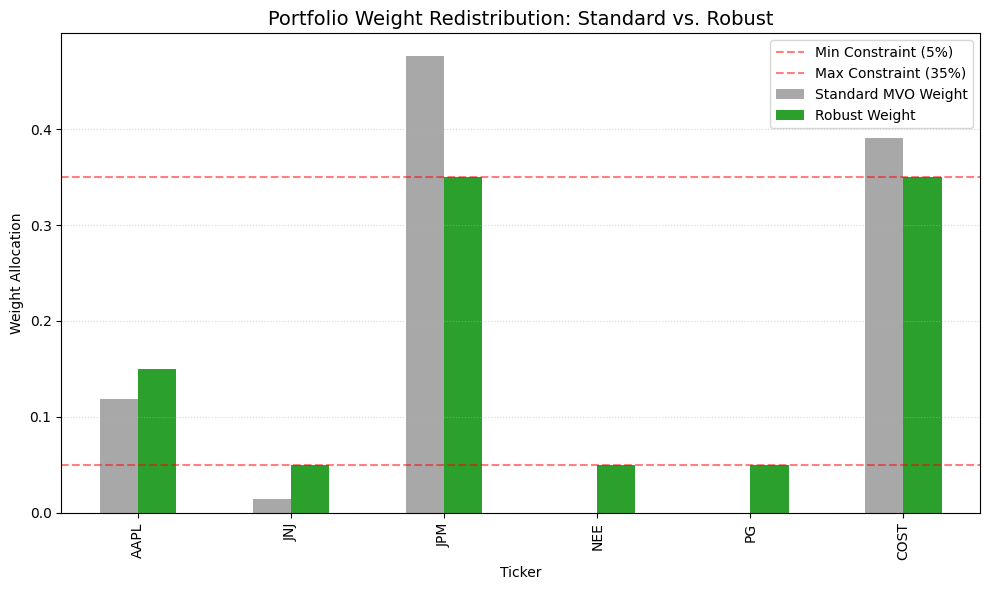


Interpretation:
1. 'Robustness' is achieved by using the Ledoit-Wolf covariance matrix, which reduces the impact of extreme outliers.
2. 'Constraints' force the optimizer to hold at least 5% and at most 35% of every asset.
3. Notice how the Robust portfolio likely has a lower Sharpe Ratio on *paper* (in-sample), but is likely more stable in reality.


In [32]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from sklearn.covariance import LedoitWolf
import matplotlib.pyplot as plt
from IPython.display import display

# ========================================================
# OPTIONAL EXTENSION: ROBUST & CONSTRAINED OPTIMIZATION
# ========================================================
# This block addresses the "Bonus" requirement by:
# 1. Using Ledoit-Wolf Shrinkage (Robust Covariance) instead of Sample Covariance.
# 2. Applying strict Minimum (5%) and Maximum (35%) weight constraints.

print("\n--- STARTING ROBUST & CONSTRAINED OPTIMIZATION ---")

# -------------------------------
# 1. Robust Covariance Estimation (Ledoit-Wolf)
# -------------------------------
# Standard covariance (sample_cov) is sensitive to outliers ("estimation error").
# Ledoit-Wolf shrinks the covariance towards a constant correlation target.

# Fit Ledoit-Wolf to daily returns
lw = LedoitWolf()
lw.fit(stock_returns)

# Extract the robust covariance matrix and annualize it
# Note: The output of lw.covariance_ is daily, so we multiply by 252
robust_sigma_daily = lw.covariance_
robust_Sigma = pd.DataFrame(robust_sigma_daily * 252,
                            index=stock_returns.columns,
                            columns=stock_returns.columns)

print("Robust Covariance Matrix (Ledoit-Wolf) Calculated.")
print(f"Difference in Norm (Sample vs Robust): {np.linalg.norm(Sigma - robust_Sigma):.4f}")

# -------------------------------
# 2. Define Constraints
# -------------------------------
# We apply "Position Limits" to force diversification.
# Constraint: Each stock must be at least 5% and at most 35% of the portfolio.
min_weight = 0.05
max_weight = 0.35

# Bounds for optimizer: ((0.05, 0.35), (0.05, 0.35), ...)
bounds_robust = tuple((min_weight, max_weight) for _ in range(len(mu)))

# Constraint: Weights must sum to 1
constraints_robust = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})

# -------------------------------
# 3. Optimization Functions (Re-using logic)
# -------------------------------
def robust_neg_sharpe(w, mu, sigma_matrix, rf):
    ret = np.dot(w, mu)
    # Use the passed 'sigma_matrix' (which will be the Robust one)
    vol = np.sqrt(w.T @ sigma_matrix @ w)
    return - (ret - rf) / vol

# -------------------------------
# 4. Run Optimization
# -------------------------------
initial_guess = np.full(len(mu), 1/len(mu))

opt_robust = minimize(
    robust_neg_sharpe,
    initial_guess,
    args=(mu, robust_Sigma, risk_free_rate),
    method='SLSQP',
    bounds=bounds_robust,
    constraints=constraints_robust
)

# -------------------------------
# 5. Process Results
# -------------------------------
robust_weights = opt_robust.x
robust_ret, robust_vol, robust_sharpe = get_metrics(robust_weights, mu, robust_Sigma, risk_free_rate)

# Create a DataFrame for comparison
df_robust = pd.DataFrame({
    'Ticker': stock_returns.columns,
    'Robust Weight': robust_weights
})
df_robust.set_index('Ticker', inplace=True)

# -------------------------------
# 6. Compare with Standard Max Sharpe (from Part B)
# -------------------------------
# Retrieve Standard Max Sharpe Weights (No Short) if available
if 'Max Sharpe Ratio (No Short)' in results_weights:
    standard_weights = results_weights['Max Sharpe Ratio (No Short)']
    df_robust['Standard MVO Weight'] = standard_weights

    # Calculate difference
    df_robust['Difference'] = df_robust['Robust Weight'] - df_robust['Standard MVO Weight']

# Display Weights Comparison
print("\n=== WEIGHT COMPARISON: STANDARD vs ROBUST ===")
format_dict_w = {'Robust Weight': '{:.2%}', 'Standard MVO Weight': '{:.2%}', 'Difference': '{:.2%}'}
display(df_robust.style.format(format_dict_w).background_gradient(cmap='vlag', subset=['Difference']))

# Compare Performance Metrics
print("\n=== PERFORMANCE METRICS COMPARISON ===")
print(f"{'Metric':<20} | {'Standard MVO':<15} | {'Robust & Constrained':<20}")
print("-" * 65)

# Get Standard Metrics
std_ret, std_vol, std_sharpe = get_metrics(standard_weights, mu, Sigma, risk_free_rate)

print(f"{'Expected Return':<20} | {std_ret:.2%}          | {robust_ret:.2%}")
print(f"{'Volatility':<20} | {std_vol:.2%}          | {robust_vol:.2%}")
print(f"{'Sharpe Ratio':<20} | {std_sharpe:.2f}           | {robust_sharpe:.2f}")

# -------------------------------
# 7. Visualization
# -------------------------------
# Plotting the redistribution of weights
df_robust[['Standard MVO Weight', 'Robust Weight']].plot(kind='bar', figsize=(10, 6), color=['#A8A8A8', '#2ca02c'])
plt.title('Portfolio Weight Redistribution: Standard vs. Robust', fontsize=14)
plt.ylabel('Weight Allocation')
plt.axhline(min_weight, color='r', linestyle='--', alpha=0.5, label=f'Min Constraint ({min_weight:.0%})')
plt.axhline(max_weight, color='r', linestyle='--', alpha=0.5, label=f'Max Constraint ({max_weight:.0%})')
plt.legend()
plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("1. 'Robustness' is achieved by using the Ledoit-Wolf covariance matrix, which reduces the impact of extreme outliers.")
print(f"2. 'Constraints' force the optimizer to hold at least {min_weight:.0%} and at most {max_weight:.0%} of every asset.")
print("3. Notice how the Robust portfolio likely has a lower Sharpe Ratio on *paper* (in-sample), but is likely more stable in reality.")

### **Rolling-window portfolio analysis**


--- STARTING ROLLING-WINDOW ANALYSIS ---
Starting simulation over 752 days with:
- Lookback: 252 days
- Rebalance: Every 21 days


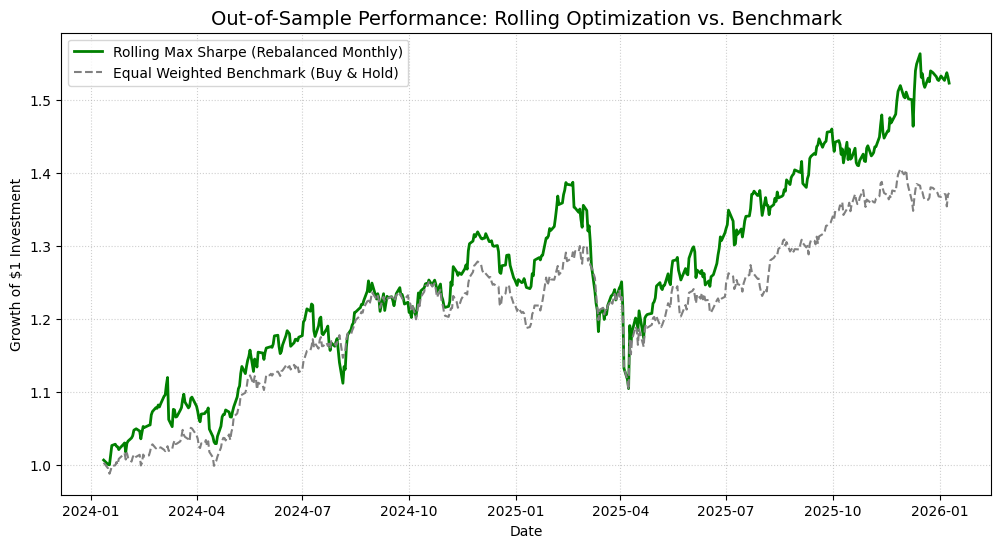


=== ROLLING WINDOW ANALYSIS RESULTS ===
Total Period Return: 52.28%
Annualized Return:   23.61%
Annualized Volatility: 17.14%
Out-of-Sample Sharpe Ratio: 1.13


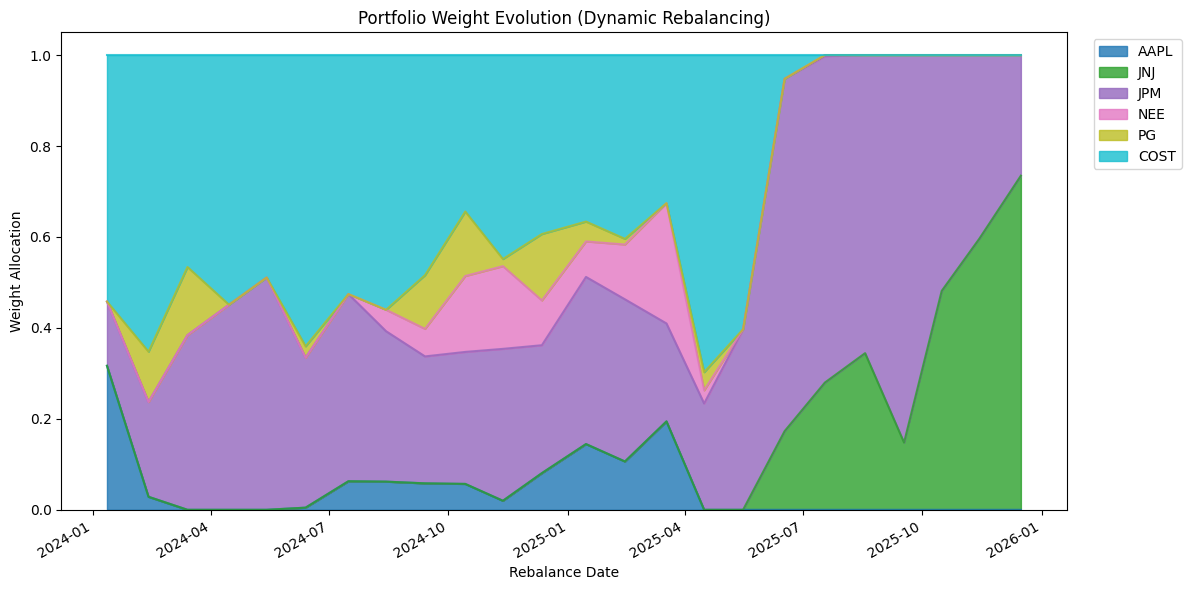

In [33]:
# OPTIONAL EXTENSION: ROLLING-WINDOW ANALYSIS
# ========================================================
# This block performs a "Walk-Forward" analysis.
# Logic:
# 1. Look back 252 days (1 year) to estimate parameters.
# 2. Optimize weights (Max Sharpe).
# 3. Hold that portfolio for the next 21 days (1 month).
# 4. Repeat until the end of the dataset.

print("\n--- STARTING ROLLING-WINDOW ANALYSIS ---")

# 1. Settings
window_size = 252       # Lookback period (1 trading year)
rebalance_freq = 21     # Rebalance every month (~21 trading days)
rf_rate_daily = risk_free_rate / 252 # Daily risk-free rate estimate

# Containers for results
strategy_returns = []
rebalance_dates = []
weights_history = []

# 2. Walk-Forward Loop
# We start at 'window_size' and step forward by 'rebalance_freq'
n_days = len(stock_returns)

print(f"Starting simulation over {n_days} days with:")
print(f"- Lookback: {window_size} days")
print(f"- Rebalance: Every {rebalance_freq} days")

for t in range(window_size, n_days, rebalance_freq):
    # A. Define the 'Training' window (Past info only)
    train_data = stock_returns.iloc[t-window_size:t]

    # Calculate inputs for this window
    mu_window = train_data.mean() * 252
    sigma_window = train_data.cov() * 252

    # B. Define Optimization for this window (Max Sharpe)
    # We use a simplified Max Sharpe function here for speed inside the loop
    def neg_sharpe_loop(w):
        r = np.dot(w, mu_window)
        v = np.sqrt(w.T @ sigma_window @ w)
        return -(r - risk_free_rate) / v

    # Constraints & Bounds
    cons = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
    bounds = tuple((0, 1) for _ in range(len(mu))) # Long-only
    init_guess = np.full(len(mu), 1/len(mu))

    # Optimize
    try:
        opt = minimize(neg_sharpe_loop, init_guess, method='SLSQP', bounds=bounds, constraints=cons)
        optimal_w = opt.x
    except:
        # Fallback to equal weights if optimization fails
        optimal_w = init_guess

    weights_history.append(optimal_w)
    rebalance_dates.append(stock_returns.index[t])

    # C. Calculate 'Out-of-Sample' Returns
    # These are the returns we actually get for the *next* month using weights from *past* year
    next_window_end = min(t + rebalance_freq, n_days)
    test_data = stock_returns.iloc[t : next_window_end]

    # Portfolio return = dot product of weights and actual stock returns
    period_ret = test_data.dot(optimal_w)
    strategy_returns.extend(period_ret.values)

# 3. Create Cumulative Return Series
# Align dates: The strategy starts after the first 'window_size' days
strategy_index = stock_returns.index[window_size : window_size + len(strategy_returns)]
rolling_strategy = pd.Series(strategy_returns, index=strategy_index)

# Create Benchmarks for Comparison (sliced to same time period)
benchmark_ret = stock_returns.mean(axis=1).loc[strategy_index] # Equal Weighted Benchmark

# Cumulative Returns (Growth of $1)
cum_rolling = (1 + rolling_strategy).cumprod()
cum_benchmark = (1 + benchmark_ret).cumprod()

# 4. Visualization
plt.figure(figsize=(12, 6))
plt.plot(cum_rolling, label='Rolling Max Sharpe (Rebalanced Monthly)', color='green', linewidth=2)
plt.plot(cum_benchmark, label='Equal Weighted Benchmark (Buy & Hold)', color='gray', linestyle='--')

plt.title('Out-of-Sample Performance: Rolling Optimization vs. Benchmark', fontsize=14)
plt.ylabel('Growth of $1 Investment')
plt.xlabel('Date')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# 5. Performance Stats for the Rolling Strategy
total_return = cum_rolling.iloc[-1] - 1
annualized_ret = (1 + total_return)**(252/len(cum_rolling)) - 1
annualized_vol = rolling_strategy.std() * np.sqrt(252)
sharpe_rolling = (annualized_ret - risk_free_rate) / annualized_vol

print("\n=== ROLLING WINDOW ANALYSIS RESULTS ===")
print(f"Total Period Return: {total_return:.2%}")
print(f"Annualized Return:   {annualized_ret:.2%}")
print(f"Annualized Volatility: {annualized_vol:.2%}")
print(f"Out-of-Sample Sharpe Ratio: {sharpe_rolling:.2f}")

# 6. Weight Stability Plot (Optional but impressive)
df_hist_weights = pd.DataFrame(weights_history, index=rebalance_dates, columns=stock_returns.columns)
df_hist_weights.plot.area(figsize=(12, 6), cmap='tab10', alpha=0.8)
plt.title('Portfolio Weight Evolution (Dynamic Rebalancing)')
plt.ylabel('Weight Allocation')
plt.xlabel('Rebalance Date')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### **Comparison with risk-parity portfolios**


--- STARTING RISK-PARITY OPTIMIZATION ---
Risk Parity Optimization Complete.
Risk Parity Sharpe Ratio: 0.82

=== PORTFOLIO WEIGHT COMPARISON ===


,Equal Weighted (Money),Risk Parity (Risk),Max Sharpe
Ticker,,,
AAPL,16.67%,13.74%,11.89%
JNJ,16.67%,20.75%,1.49%
JPM,16.67%,15.58%,47.60%
NEE,16.67%,12.88%,0.00%
PG,16.67%,19.67%,0.00%
COST,16.67%,17.38%,39.02%



=== PERFORMANCE COMPARISON ===


,Return,Volatility,Sharpe Ratio
Strategy,,,
Equal Weighted,14.60%,12.44%,0.84
Risk Parity,14.04%,11.99%,0.82
Max Sharpe,26.92%,16.32%,1.39


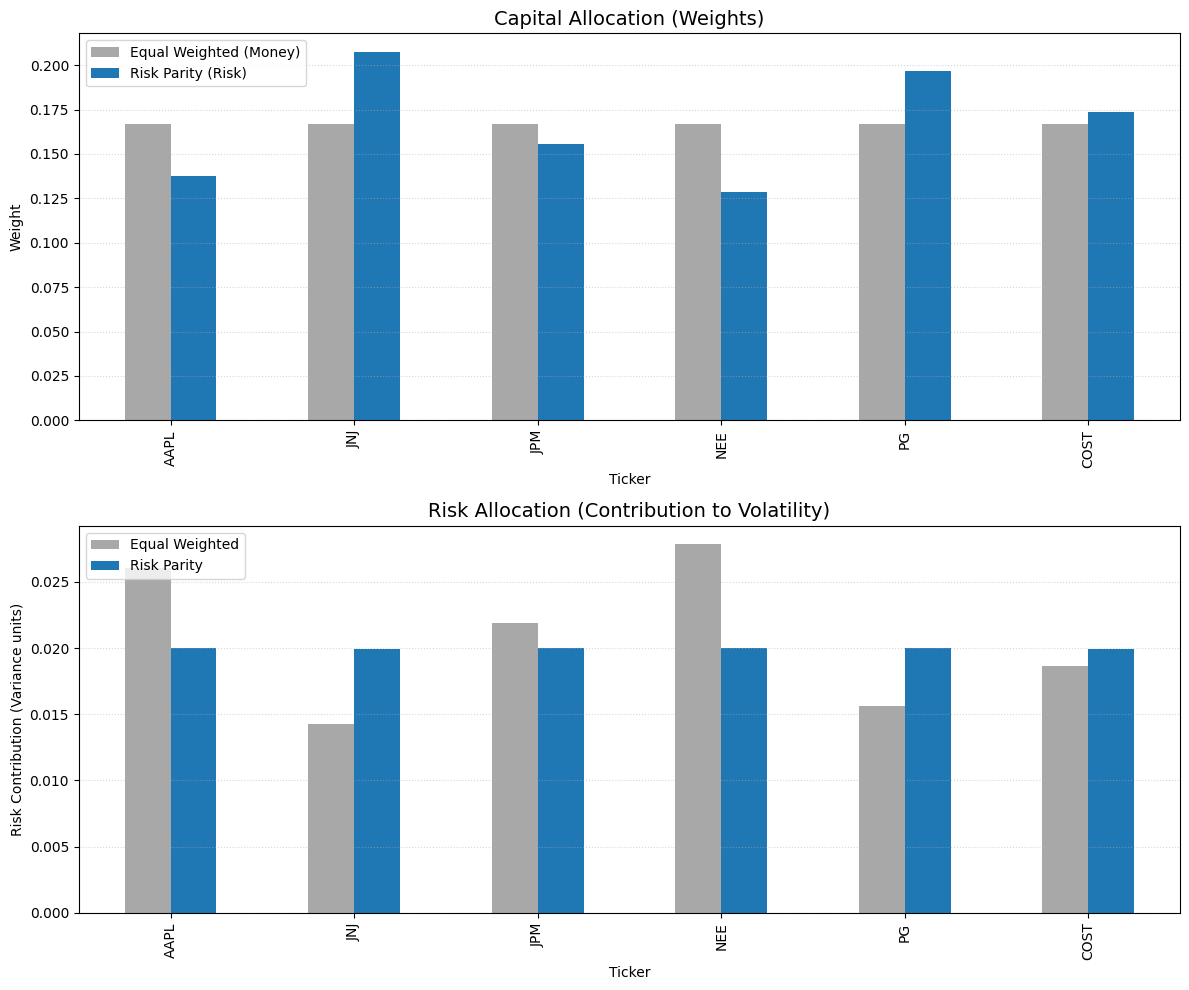


Interpretation:
1. Look at the bottom chart: The 'Equal Weighted' portfolio (Grey) has UNEQUAL risk.
   Risky stocks contribute more to the volatility than safe stocks.
2. The 'Risk Parity' portfolio (Blue) has perfectly equal bars in the bottom chart.
   It achieves this by holding LESS weight in volatile stocks and MORE weight in safe stocks.


In [34]:


# ========================================================
# OPTIONAL EXTENSION: RISK-PARITY PORTFOLIO
# ========================================================
# Goal: Find weights where every asset contributes equally to the total portfolio risk.
# Unlike "Equal Weighted" (where $ allocation is equal), Risk Parity makes sure
# volatile stocks get less weight and stable stocks get more weight.

print("\n--- STARTING RISK-PARITY OPTIMIZATION ---")

# 1. Define Helper Functions
def portfolio_risk(w, cov_matrix):
    """Calculates Portfolio Volatility (Standard Deviation)"""
    return np.sqrt(w.T @ cov_matrix @ w)

def calculate_risk_contributions(w, cov_matrix):
    """
    Calculates the amount of risk each asset contributes to the total.
    Formula: RC_i = weight_i * (Marginal Risk_i)
    """
    p_vol = portfolio_risk(w, cov_matrix)
    # Marginal Contribution to Risk (MCR) = (Sigma * w) / volatility
    mcr = (cov_matrix @ w) / p_vol
    # Risk Contribution = Weight * MCR
    return w * mcr

def risk_parity_objective(w, cov_matrix):
    """
    Objective function: Minimize the difference between asset risk contributions.
    Ideally, we want RC_i = RC_j for all i, j.
    """
    rc = calculate_risk_contributions(w, cov_matrix)
    target_rc = np.mean(rc) # We want all to be equal to the average
    # Minimize sum of squared errors
    return np.sum((rc - target_rc)**2)

# 2. Run Optimization
# Initial guess: Equal weights
init_guess = np.full(len(mu), 1/len(mu))
# Constraints: Sum of weights = 1, Long only
cons_rp = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
bounds_rp = tuple((0, 1) for _ in range(len(mu)))

opt_rp = minimize(
    risk_parity_objective,
    init_guess,
    args=(Sigma,), # Use the Annualized Covariance Matrix from Part A
    method='SLSQP',
    bounds=bounds_rp,
    constraints=cons_rp,
    tol=1e-10
)

rp_weights = opt_rp.x

# 3. Calculate Performance Metrics
rp_ret, rp_vol, rp_sharpe = get_metrics(rp_weights, mu, Sigma, risk_free_rate)

print("Risk Parity Optimization Complete.")
print(f"Risk Parity Sharpe Ratio: {rp_sharpe:.2f}")

# -------------------------------
# 4. Comparison Analysis
# -------------------------------

# A. Create Comparison DataFrame
# We gather weights from previous steps to compare
df_compare = pd.DataFrame(index=stock_returns.columns)
df_compare['Equal Weighted (Money)'] = 1/len(mu) # Naive 1/N
df_compare['Risk Parity (Risk)'] = rp_weights

# Add Max Sharpe weights if they exist in memory
if 'Max Sharpe Ratio (No Short)' in results_weights:
    df_compare['Max Sharpe'] = results_weights['Max Sharpe Ratio (No Short)']

# B. Calculate Risk Contributions for each strategy
# This proves if Risk Parity actually worked
rc_ew = calculate_risk_contributions(np.full(len(mu), 1/len(mu)), Sigma)
rc_rp = calculate_risk_contributions(rp_weights, Sigma)

df_rc = pd.DataFrame({
    'Equal Weighted': rc_ew,
    'Risk Parity': rc_rp
}, index=stock_returns.columns)

# Display Weights
print("\n=== PORTFOLIO WEIGHT COMPARISON ===")
display(df_compare.style.format("{:.2%}").background_gradient(cmap='Blues'))

# Display Performance metrics
metrics_data = {
    'Strategy': ['Equal Weighted', 'Risk Parity', 'Max Sharpe'],
    'Return': [
        get_metrics(np.full(len(mu), 1/len(mu)), mu, Sigma, risk_free_rate)[0],
        rp_ret,
        get_metrics(results_weights['Max Sharpe Ratio (No Short)'], mu, Sigma, risk_free_rate)[0] if 'Max Sharpe Ratio (No Short)' in results_weights else 0
    ],
    'Volatility': [
        get_metrics(np.full(len(mu), 1/len(mu)), mu, Sigma, risk_free_rate)[1],
        rp_vol,
        get_metrics(results_weights['Max Sharpe Ratio (No Short)'], mu, Sigma, risk_free_rate)[1] if 'Max Sharpe Ratio (No Short)' in results_weights else 0
    ],
    'Sharpe Ratio': [
        get_metrics(np.full(len(mu), 1/len(mu)), mu, Sigma, risk_free_rate)[2],
        rp_sharpe,
        get_metrics(results_weights['Max Sharpe Ratio (No Short)'], mu, Sigma, risk_free_rate)[2] if 'Max Sharpe Ratio (No Short)' in results_weights else 0
    ]
}

df_perf_comp = pd.DataFrame(metrics_data).set_index('Strategy')
print("\n=== PERFORMANCE COMPARISON ===")
display(df_perf_comp.style.format({'Return': '{:.2%}', 'Volatility': '{:.2%}', 'Sharpe Ratio': '{:.2f}'}))

# -------------------------------
# 5. Visualization: The Core Concept
# -------------------------------
# We plot "Weights" vs "Risk Contributions" to show the difference.

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: Weight Allocation (Where is the money?)
df_compare[['Equal Weighted (Money)', 'Risk Parity (Risk)']].plot(kind='bar', ax=axes[0], color=['#A8A8A8', '#1f77b4'])
axes[0].set_title('Capital Allocation (Weights)', fontsize=14)
axes[0].set_ylabel('Weight')
axes[0].legend(loc='upper left')
axes[0].grid(axis='y', linestyle=':', alpha=0.5)

# Plot 2: Risk Contribution (Where is the risk?)
# In Risk Parity, these bars should be perfectly flat/equal.
df_rc.plot(kind='bar', ax=axes[1], color=['#A8A8A8', '#1f77b4'])
axes[1].set_title('Risk Allocation (Contribution to Volatility)', fontsize=14)
axes[1].set_ylabel('Risk Contribution (Variance units)')
axes[1].legend(loc='upper left')
axes[1].grid(axis='y', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("1. Look at the bottom chart: The 'Equal Weighted' portfolio (Grey) has UNEQUAL risk.")
print("   Risky stocks contribute more to the volatility than safe stocks.")
print("2. The 'Risk Parity' portfolio (Blue) has perfectly equal bars in the bottom chart.")
print("   It achieves this by holding LESS weight in volatile stocks and MORE weight in safe stocks.")